In [30]:
import sys
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt

### Carga de la data limpia

In [31]:
data = pd.read_csv("./../datasets/datosRed_limpio.csv", encoding="ISO-8859-1")
data.head()

,AÑO,PERSONA,TIPO DE SERVICIO,NOMBRE DE LA TAREA,MODALIDAD,COMPLEJIDAD
0,2019,ID_1,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
1,2019,ID_2,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
2,2019,ID_3,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
3,2019,ID_4,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
4,2019,ID_5,SERV_1,TAREA_1.1,PRESENCIAL,BAJA


### Construccion de la red bipartita cliente-servicio

In [32]:
B = nx.Graph()
clientes = data['PERSONA'].unique().tolist()
servicios = data['TIPO DE SERVICIO'].unique().tolist()

# Añadir nodos con el atributo 'bipartite'
B.add_nodes_from(clientes, bipartite="cliente", tipo="CLIENTE")
B.add_nodes_from(servicios, bipartite="servicio", tipo="SERVICIO")

# Añadir aristas entre clientes y servicios
for _, row in data.iterrows():
    cli = row['PERSONA']
    serv = row['TIPO DE SERVICIO']
    if not B.has_edge(cli, serv):
        B.add_edge(cli, serv)

conj_clientes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'cliente']

#Proyeccion ponderada de clientes
G_weighted = bipartite.weighted_projected_graph(B, conj_clientes)

#Proyeccion no ponderada de clientes
G_unweighted = bipartite.projected_graph(B, conj_clientes)

#Utilizamos la ponderada para el analisis
G = G_weighted

### Visualizacion

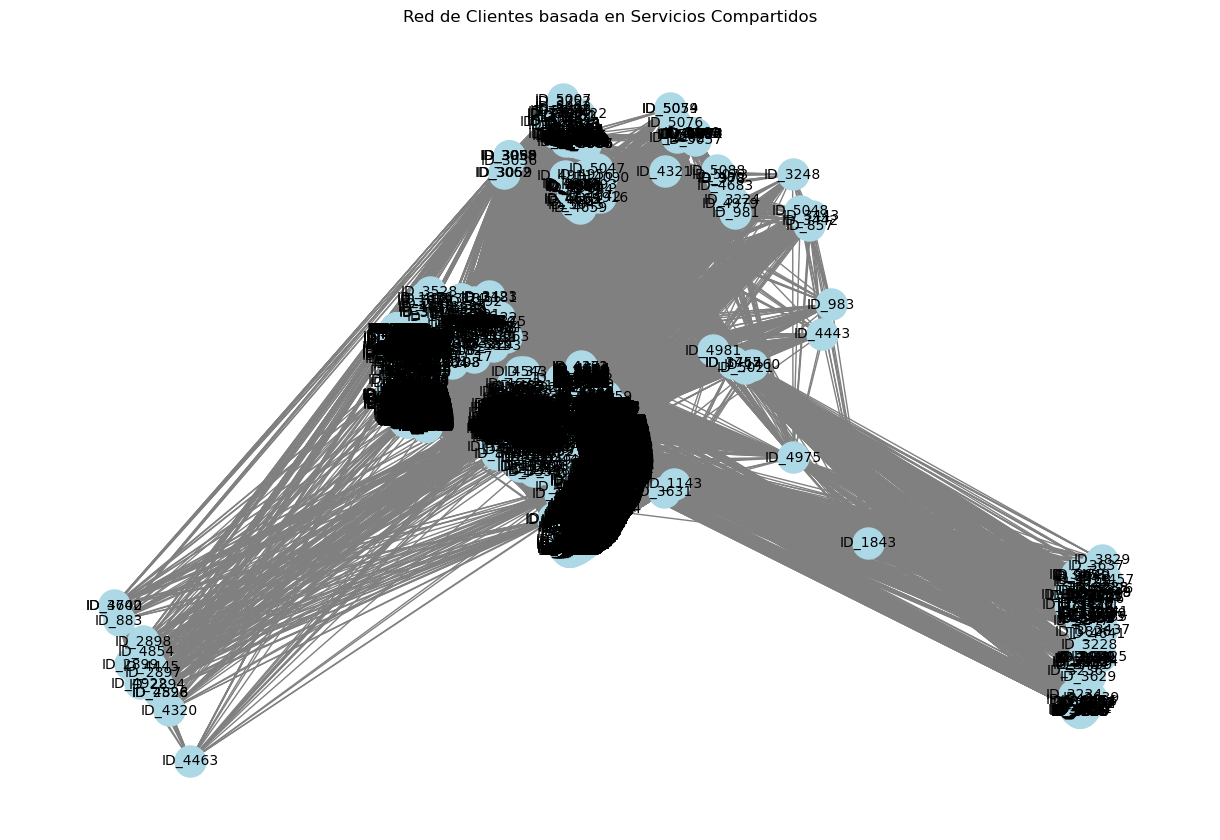

In [33]:
#visualizar el grafo
Graph = plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Posiciones para todos los nod
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=10)
plt.title("Red de Clientes basada en Servicios Compartidos")
plt.show()

### Primeras metricas

In [34]:
#Numeros de nodos
n = G.number_of_nodes()
#Numero de aristas
m = G.number_of_edges()
#Densidad
densidad = nx.density(G)
#Grados
grados = dict(G.degree())
#Grado medio
grado_medio = sum(grados.values()) / n if n > 0 else 0

print("````Primeras métricas de la red de clientes```")
print(f"Nodos (clientes): {n}")
print(f"Enlaces (cliente-cliente): {m}")
print(f"Densidad: {densidad:.4f}")
print(f"Grado medio: {grado_medio:.2f}")

````Primeras métricas de la red de clientes```
Nodos (clientes): 5090
Enlaces (cliente-cliente): 7189307
Densidad: 0.5551
Grado medio: 2824.88


### Comunidades

In [35]:
try:
    import community as community_louvain  # paquete "python-louvain"
    LOUVAIN_AVAILABLE = True
except Exception:
    LOUVAIN_AVAILABLE = False

In [36]:
if LOUVAIN_AVAILABLE and G.number_of_nodes() > 0:
    part = community_louvain.best_partition(G, weight="weight")
    # modularidad
    modularidad = community_louvain.modularity(part, G, weight="weight")
    print(f"Algoritmo: Louvain | Comunidades detectadas: {len(set(part.values()))}")
    print(f"Modularidad: {modularidad:.4f}")
else:
    if G.number_of_nodes() > 0:
        comms = nx.algorithms.community.greedy_modularity_communities(G, weight="weight")
        modularidad = nx.algorithms.community.modularity(G, comms, weight="weight")
        print(f"Algoritmo: Greedy Modularity | Comunidades detectadas: {len(comms)}")
        print(f"Modularidad: {modularidad:.4f}")
        # Convertir a dict tipo {nodo: comunidad_id}
        part = {}
        for cid, cset in enumerate(comms):
            for node in cset:
                part[node] = cid
    else:
        part, modularidad = {}, 0.0
        print("Grafo vacío: no hay comunidades")

Algoritmo: Greedy Modularity | Comunidades detectadas: 4
Modularidad: 0.2881


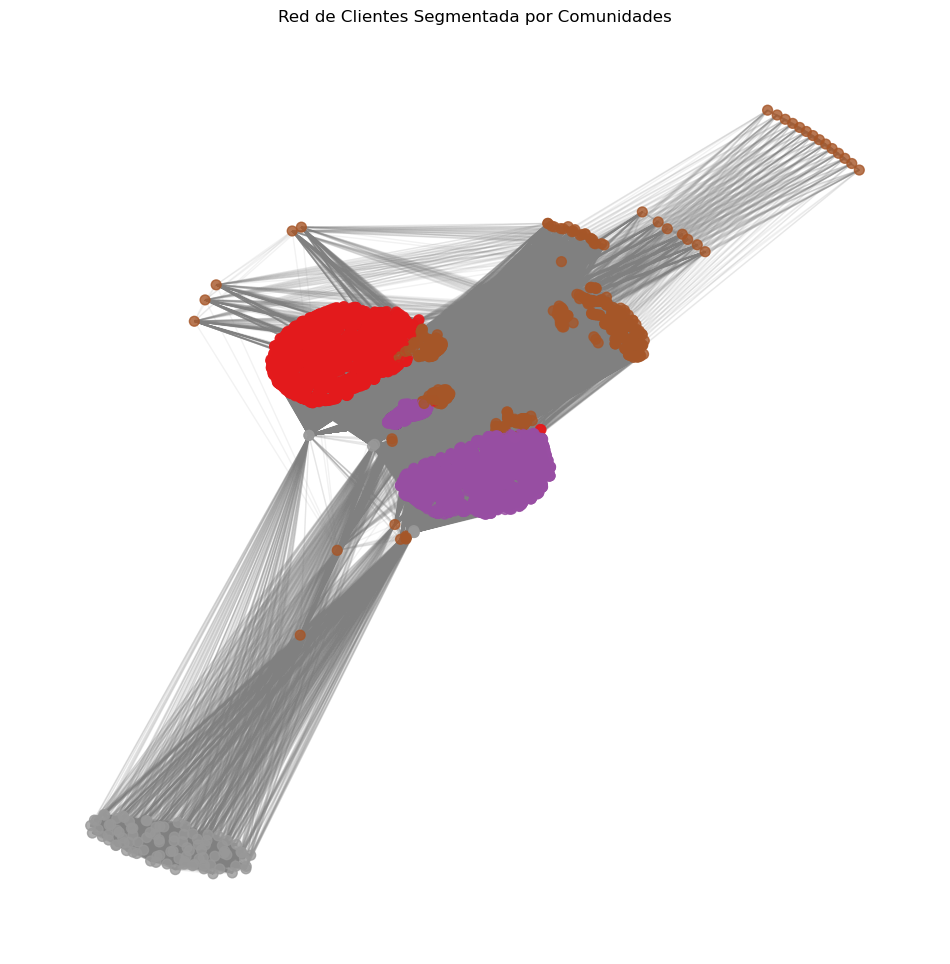

In [38]:
# --- VISUALIZACIÓN DE COMUNIDADES ---

# 1. Asignar colores según la comunidad
# 'part' es el diccionario {nodo: comunidad}
comunidades = [part.get(node) for node in G.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42, k=0.1) # k ajusta la separación

# Dibuja los nodos coloreados por comunidad
nx.draw_networkx_nodes(G, pos, 
                       node_size=50, 
                       cmap=plt.cm.Set1, # Paleta de colores
                       node_color=comunidades, 
                       alpha=0.8)

# Dibujar aristas (más finas y transparentes para que no tapen)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

plt.title("Red de Clientes Segmentada por Comunidades")
plt.axis('off')
plt.show()

In [39]:
# --- IDENTIFICACIÓN DE HUBS POR COMUNIDAD ---

# Calcula el Grado (importancia) de cada cliente
grado = dict(G.degree(weight='weight'))

# Añade el grado al DataFrame de análisis que creamos antes
df_analisis['Grado'] = df_analisis['PERSONA'].map(grado)

# Obtenemos el top 3 de clientes más importantes de cada comunidad
top_clientes = df_analisis.sort_values(['Comunidad', 'Grado'], ascending=[True, False]).groupby('Comunidad').head(3)

print("--- Clientes Clave (Hubs) por Comunidad ---")
print(top_clientes[['Comunidad', 'PERSONA', 'Grado', 'MODALIDAD', 'COMPLEJIDAD']])

--- Clientes Clave (Hubs) por Comunidad ---
      Comunidad  PERSONA  Grado   MODALIDAD COMPLEJIDAD
344           0  ID_4672   5604  PRESENCIAL        BAJA
345           0  ID_4672   5604  PRESENCIAL     MEDIANA
346           0  ID_4672   5604     VIRTUAL        BAJA
4796          1  ID_3124   6186  PRESENCIAL        BAJA
4797          1  ID_3124   6186  PRESENCIAL        BAJA
4798          1  ID_3124   6186  PRESENCIAL        BAJA


In [41]:
# --- MÉTRICAS  ---
from networkx.algorithms import approximation

print(f"--- Dimensiones de la Red Filtrada ---")
print(f"Nodos: {G.number_of_nodes()}")
print(f"Enlaces: {G.number_of_edges()}")

print(f"\n--- Métrica: DENSIDAD ---")
print(f"Filtrada: {nx.density(G):.4f}")

print(f"\n--- Métrica: CLUSTERING (Estimado) ---")
# 'trials=1000' toma una muestra de 1000 nodos.
#  Esta aproximación ignora los pesos, pero da la estructura topológica.
clustering_aprox = approximation.average_clustering(G, trials=3000)
print(f"Filtrada (Aprox): {clustering_aprox:.4f}")

--- Dimensiones de la Red Filtrada ---
Nodos: 5090
Enlaces: 7189307

--- Métrica: DENSIDAD ---
Filtrada: 0.5551

--- Métrica: CLUSTERING (Estimado) ---
Filtrada (Aprox): 0.9507
